In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Read in all results and combine into a single dataframe:

results_dir = ''
#results_dir = '/content/drive/MyDrive/Colab Notebooks/Reker Lab ML/results/'

df_ls = []
for ds in ['Tyro', 'Acetyl', 'Mono']:

    # Read CV results:
    df = pd.read_csv(results_dir+ds+'-Mixture-CVAvg_stats.csv')
    df['Dataset'] = ds
    df['Test'] = 'Mix'
    df_ls.append(df)

# Combine separate dataframes:
df = pd.concat(df_ls)\
       .drop(columns=['Fold', 'Index'])

# Identify non-numeric columns and exclude them from aggregation
numeric_cols = df.select_dtypes(include=np.number).columns
df = df.groupby(['Test', 'Dataset', 'Descriptor', 'Model'])[numeric_cols] \
       .agg(['mean','std'])
#df_grouped.head()
df.head()

Number of Molecules             r2            \
                                             mean  std      mean       std   
Test Dataset Descriptor Model                                                
Mix  Acetyl  Both       RF                 5076.0  0.0  0.699396  0.003327   
                        SVR                5076.0  0.0  0.668923  0.002696   
                        XGBR               5076.0  0.0  0.701476  0.004208   
             Morgan     RF                 5076.0  0.0  0.698825  0.001587   
                        SVR                5076.0  0.0  0.652934  0.001712   

                                   rmsd                bias            \
                                   mean       std      mean       std   
Test Dataset Descriptor Model                                           
Mix  Acetyl  Both       RF     0.714805  0.003331  0.016009  0.003666   
                        SVR    0.750457  0.003174 -0.027654  0.002403   
                        XGBR   0.711773  0.004699  0.014245  0.006369   
             Morgan     RF     0.715348  0.001928  0.020817  0.000338   
                        SVR    0.768263  0.001855 -0.027051  0.002989   

                                   sdep            
                                   mean       std  
Test Dataset Descriptor Model                      
Mix  Acetyl  Both       RF     0.713509  0.003040  
                        SVR    0.749339  0.002942  
                        XGBR   0.710831  0.004875  
             Morgan     RF     0.714245  0.001914  
                        SVR    0.766568  0.001908

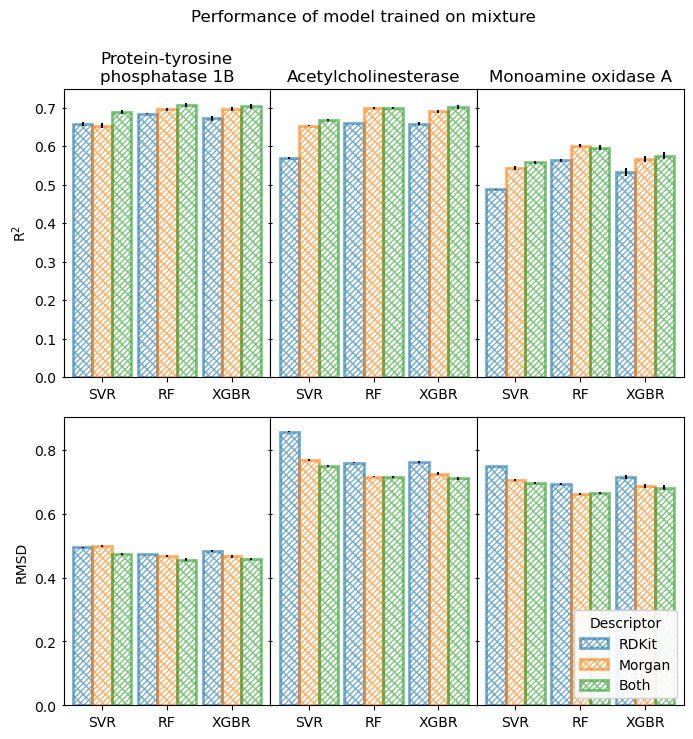

In [7]:
# Plot results:

fig, ax = plt.subplots(2, 3, figsize=(8, 8), sharey='row', 
                       gridspec_kw={'wspace' : 0, 
                                    'hspace' : 0.14})

bar_width = 0.3
models = ['SVR', 'RF', 'XGBR']
bar_colours = ['tab:blue', 'tab:orange', 'tab:green']

# Add axis line at y=0:
ax[0, 0].axhline(0, c='black', lw=0.7)
ax[0, 1].axhline(0, c='black', lw=0.7)
ax[0, 2].axhline(0, c='black', lw=0.7)

for s_i, stats in enumerate(['r2', 'rmsd']):
    for d_i, dataset in enumerate(['Tyro', 'Acetyl', 'Mono']):
        for i, desc in enumerate(['RDKit', 'Morgan', 'Both']):

            ax[s_i, d_i].bar(np.arange(len(df.loc[('Mix', dataset, desc)].loc[models]))+bar_width*(i-1), 
                           height=df.loc[('Mix', dataset, desc), (stats, 'mean')].loc[models], 
                           width=bar_width, 
                           label=desc, 
                           alpha=0.6, 
                           # fc='empty', 
                           ec=bar_colours[i], 
                           fc=bar_colours[i], 
                           lw=2, 
                           fill=False, 
                           hatch='//////\\\\\\',
                           yerr=df.loc[('Mix', dataset, desc), (stats, 'std')].loc[models])
            
        ax[s_i, d_i].set_xticks([0, 1, 2])
        ax[s_i, d_i].set_xticklabels(models)
        ax[s_i, d_i].tick_params(axis="y", direction="inout")

ax[0, 0].set_title('Protein-tyrosine\nphosphatase 1B')
ax[0, 1].set_title('Acetylcholinesterase')
ax[0, 2].set_title('Monoamine oxidase A')

ax[0, 0].set_ylabel('R$^{2}$')
ax[1, 0].set_ylabel('RMSD')

fig.suptitle('Performance of model trained on mixture')

# Modify legend:
plt.legend(loc='lower right', title='Descriptor', framealpha=0.9)

plt.savefig('Mix_results_bar_chart.png', dpi=400)
plt.show()